# XGBoost — Non-Temporal v3

**Dataset:** `dataset/temporal/output/cleaned_human_readable.csv`  
**Target:** `treatment_outcome_binary` — 0 = Success (Cured / Treatment Completed), 1 = Failure (Died / Lost to Follow-Up / Failed)  
**Features:** All static baseline columns + M0 temporal features only (M1–M12 dropped)  
**Leakage prevention:** Train/test split is performed *before* any scaling. The `StandardScaler` and `OneHotEncoder` are fit exclusively on the training set and then applied to both sets.  
**Class imbalance:** Handled via `scale_pos_weight` (majority-to-minority ratio computed on training labels only).

In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
np.random.seed(42)

DATASET_PATH = '../../dataset/temporal/output/cleaned_human_readable.csv'
RANDOM_STATE = 42
TEST_SIZE    = 0.2

## 1. Load Data & Derive Target Variable

In [2]:
df_raw = pd.read_csv(DATASET_PATH)
print(f'Raw dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
print('\nOutcome distribution (raw):')
print(df_raw['outcome'].value_counts())

Raw dataset: 599 rows, 266 columns

Outcome distribution (raw):
outcome
Treatment Completed    489
Lost to Follow-Up       52
Cured                   47
Died                     9
Not Evaluated            2
Name: count, dtype: int64


In [3]:
SUCCESS_OUTCOMES = {'Cured', 'Treatment Completed'}
FAILURE_OUTCOMES = {'Failed', 'Died', 'Lost to Follow-Up'}
ALL_OUTCOMES     = SUCCESS_OUTCOMES | FAILURE_OUTCOMES

df = df_raw[df_raw['outcome'].isin(ALL_OUTCOMES)].copy()
df['treatment_outcome_binary'] = df['outcome'].apply(
    lambda x: 0 if x in SUCCESS_OUTCOMES else 1
)

n_excluded = len(df_raw) - len(df)
print(f'Retained: {len(df)} rows  |  Excluded (ambiguous outcomes): {n_excluded}')
print('\nClass distribution:')
print(df['treatment_outcome_binary'].value_counts().rename({0: 'Success (0)', 1: 'Failure (1)'}))

Retained: 597 rows  |  Excluded (ambiguous outcomes): 2

Class distribution:
treatment_outcome_binary
Success (0)    536
Failure (1)     61
Name: count, dtype: int64


## 2. Feature Engineering from Date Columns

In [4]:
date_cols_to_parse = [
    'date_of_birth', 'date_of_diagnosis', 'date_of_notification',
    'treatment_start_date', 'intensive_phase_start_date', 'intensive_phase_end_date',
    'continuation_phase_start_date', 'continuation_phase_end_date', 'date_of_outcome'
]
for col in date_cols_to_parse:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'date_of_diagnosis' in df.columns and 'date_of_notification' in df.columns:
    df['diagnosis_delay_days'] = (
        df['date_of_diagnosis'] - df['date_of_notification']
    ).dt.days.clip(0, 365)

if 'treatment_start_date' in df.columns and 'date_of_diagnosis' in df.columns:
    df['days_to_treatment'] = (
        df['treatment_start_date'] - df['date_of_diagnosis']
    ).dt.days.clip(0, 365)

if 'intensive_phase_start_date' in df.columns and 'intensive_phase_end_date' in df.columns:
    df['intensive_phase_duration_days'] = (
        df['intensive_phase_end_date'] - df['intensive_phase_start_date']
    ).dt.days.clip(0, None)

if 'continuation_phase_start_date' in df.columns and 'continuation_phase_end_date' in df.columns:
    df['continuation_phase_duration_days'] = (
        df['continuation_phase_end_date'] - df['continuation_phase_start_date']
    ).dt.days.clip(0, None)

print('Derived features added:')
derived = ['diagnosis_delay_days', 'days_to_treatment',
           'intensive_phase_duration_days', 'continuation_phase_duration_days']
for f in derived:
    if f in df.columns:
        print(f'  {f}: non-null={df[f].notna().sum()}, median={df[f].median():.1f}')

Derived features added:
  diagnosis_delay_days: non-null=597, median=0.0
  days_to_treatment: non-null=597, median=1.0
  intensive_phase_duration_days: non-null=597, median=55.0
  continuation_phase_duration_days: non-null=597, median=111.0


## 3. Drop Leakage Columns & M1–M12 Temporal Columns

In [5]:
DROP_ALWAYS   = ['no', 'patient_id', 'source_file', 'outcome', 'date_of_outcome']
DROP_DATES    = [
    'date_of_birth', 'date_of_diagnosis', 'date_of_notification',
    'treatment_start_date', 'intensive_phase_start_date', 'intensive_phase_end_date',
    'continuation_phase_start_date', 'continuation_phase_end_date'
]
DROP_RAW_DUPES = ['height', 'weight']
DROP_M1_M12   = [c for c in df.columns if re.match(r'^M([1-9]|1[0-2])_', c)]

all_drops = [c for c in DROP_ALWAYS + DROP_DATES + DROP_RAW_DUPES + DROP_M1_M12
             if c in df.columns]

df.drop(columns=all_drops, inplace=True)

print(f'Dropped {len(all_drops)} columns. Remaining: {df.shape[1]} columns')
print(f'  Identifiers/leakage: {len([c for c in DROP_ALWAYS if c in all_drops])}')
print(f'  Date columns:        {len([c for c in DROP_DATES if c in all_drops])}')
print(f'  Raw dupes:           {len([c for c in DROP_RAW_DUPES if c in all_drops])}')
print(f'  M1–M12 temporal:     {len(DROP_M1_M12)}')

Dropped 207 columns. Remaining: 64 columns
  Identifiers/leakage: 5
  Date columns:        8
  Raw dupes:           2
  M1–M12 temporal:     192


## 4. Train / Test Split  *(before any scaling)*

In [6]:
X = df.drop(columns=['treatment_outcome_binary'])
y = df['treatment_outcome_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')
print(f'\nClass distribution — Train:')
print(y_train.value_counts().rename({0: 'Success (0)', 1: 'Failure (1)'}))
print(f'\nClass distribution — Test:')
print(y_test.value_counts().rename({0: 'Success (0)', 1: 'Failure (1)'}))

# scale_pos_weight: ratio of negative (Success=0) to positive (Failure=1) in training set
# Computed ONLY from y_train to prevent leakage
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nscale_pos_weight = {scale_pos_weight:.2f} (majority/minority ratio in train set)')

Train: 477 samples  |  Test: 120 samples

Class distribution — Train:
treatment_outcome_binary
Success (0)    428
Failure (1)     49
Name: count, dtype: int64

Class distribution — Test:
treatment_outcome_binary
Success (0)    108
Failure (1)     12
Name: count, dtype: int64

scale_pos_weight = 8.73 (majority/minority ratio in train set)


## 5. Preprocessing Pipeline  *(fit on train only)*

In [7]:
numeric_cols     = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features:     {len(numeric_cols)}')
print(f'Categorical features: {len(categorical_cols)}')
print('\nSample numeric cols:', numeric_cols[:8])
print('Sample categorical cols:', categorical_cols[:8])

Numeric features:     50
Categorical features: 13

Sample numeric cols: ['age', 'xpert_mtb_rif', 'smear_microscopy', 'heart_rate', 'o2_sat', 'data_year', 'weight_kg', 'height_cm']
Sample categorical cols: ['name_of_diagnosing_facility', 'sex', 'civil_status', 'nationality', 'chest_x_ray_at_case_notification', 'diagnosis', 'bacteriologic_status', 'case_registration_group']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                                             numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='drop'
)

## 6. Build & Train XGBoost Pipeline

In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,  # computed from y_train only
    n_jobs=-1,
    verbosity=0,
    eval_metric='logloss'
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   model)
])

import time
t0 = time.time()
pipe.fit(X_train, y_train)
print(f'Training complete in {time.time() - t0:.2f}s')

Training complete in 0.40s


## 7. Evaluation

In [10]:
y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Success (0)', 'Failure (1)'],
    zero_division=0
))

Accuracy : 0.8917
ROC-AUC  : 0.9398

              precision    recall  f1-score   support

 Success (0)       0.97      0.91      0.94       108
 Failure (1)       0.47      0.75      0.58        12

    accuracy                           0.89       120
   macro avg       0.72      0.83      0.76       120
weighted avg       0.92      0.89      0.90       120



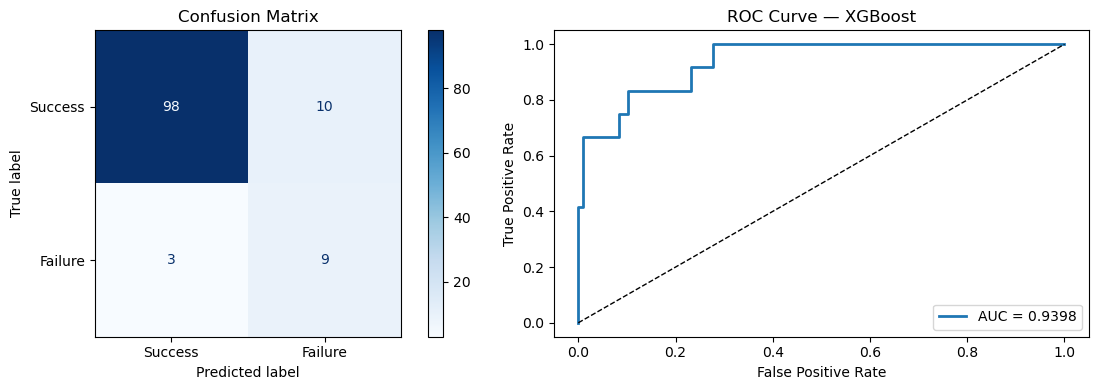

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Success', 'Failure'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — XGBoost')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 8. Feature Importance (Gain-based)

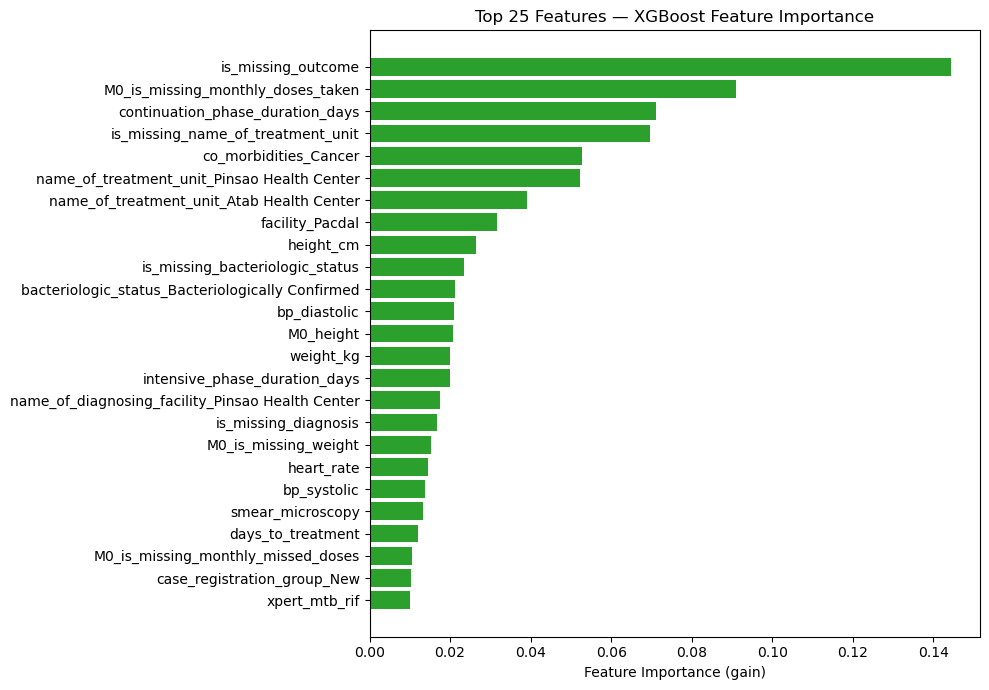

In [12]:
xgb = pipe.named_steps['classifier']
ct  = pipe.named_steps['preprocessor']

num_names = numeric_cols
cat_names = ct.named_transformers_['cat']['ohe'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = num_names + cat_names

importance_vals = xgb.feature_importances_
importance_df = pd.DataFrame({
    'feature':    all_feature_names,
    'importance': importance_vals
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['feature'], importance_df['importance'], color='#2ca02c')
plt.xlabel('Feature Importance (gain)')
plt.title('Top 25 Features — XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

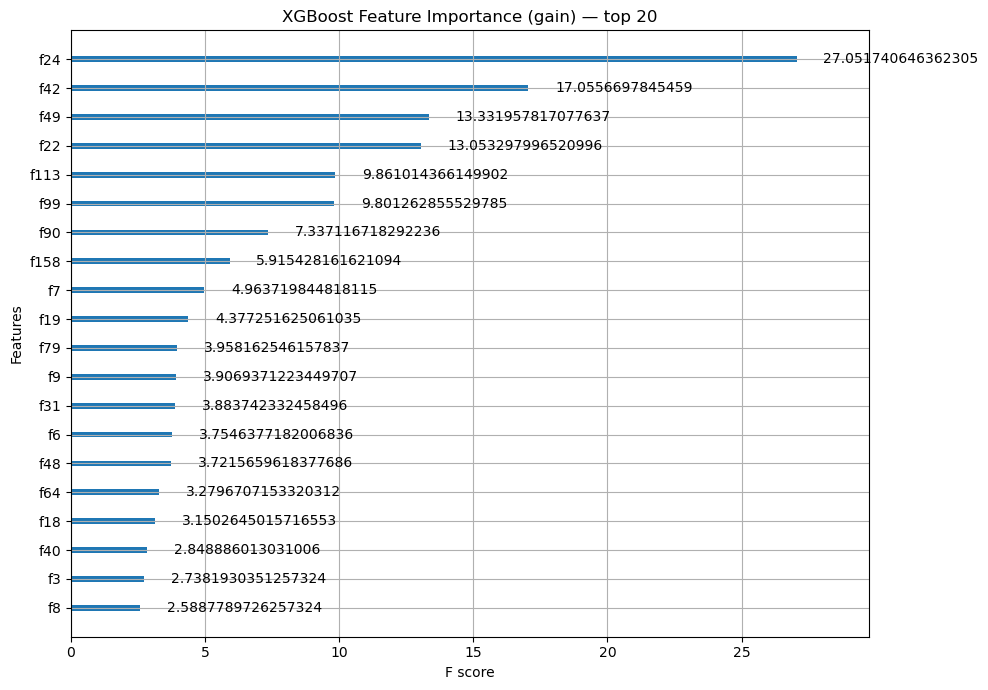

In [13]:
# XGBoost native importance plot (by 'weight', 'gain', or 'cover')
fig, ax = plt.subplots(figsize=(10, 7))
plot_importance(xgb, ax=ax, importance_type='gain', max_num_features=20,
                title='XGBoost Feature Importance (gain) — top 20')
plt.tight_layout()
plt.show()